Jujube — DETECTED PEAK WAVELENGTHS
Sample       wl_520   wl_684_actual   wl_737_actual
-------------------------------------------------------
B1           520.00          680.18          727.17
B2           520.00          677.90          726.41
B3           520.00          686.26          733.21

Jujube — KEY WAVELENGTH INTENSITIES (normalized)
Sample      I520(Car)   I_pk684(Chla)   I_pk737(Chlb)
-------------------------------------------------------
B1           0.001887        0.006527        0.003206
B2           0.001951        0.005908        0.002953
B3           0.001977        0.004350        0.003076

Jujube — SPECTRAL RATIOS (dynamic peak detection)
Sample         I684/I520       I684/I737     (I684+I737)/I520
-----------------------------------------------------------------
B1                3.4594          2.0358               5.1587
B2                3.0277          2.0006               4.5411
B3                2.2002          1.4144               3.7557


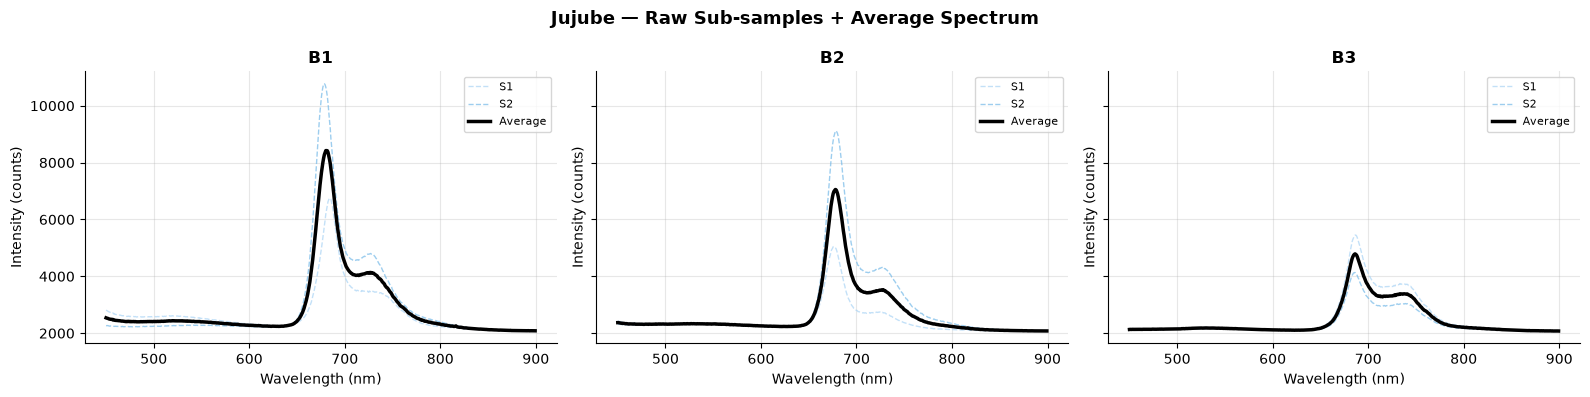

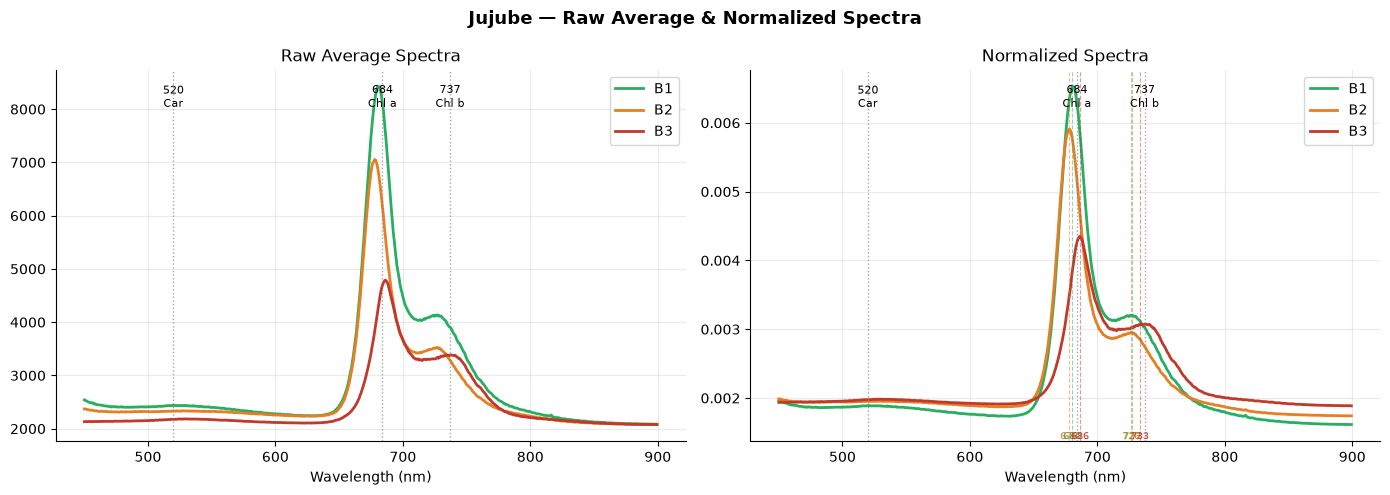

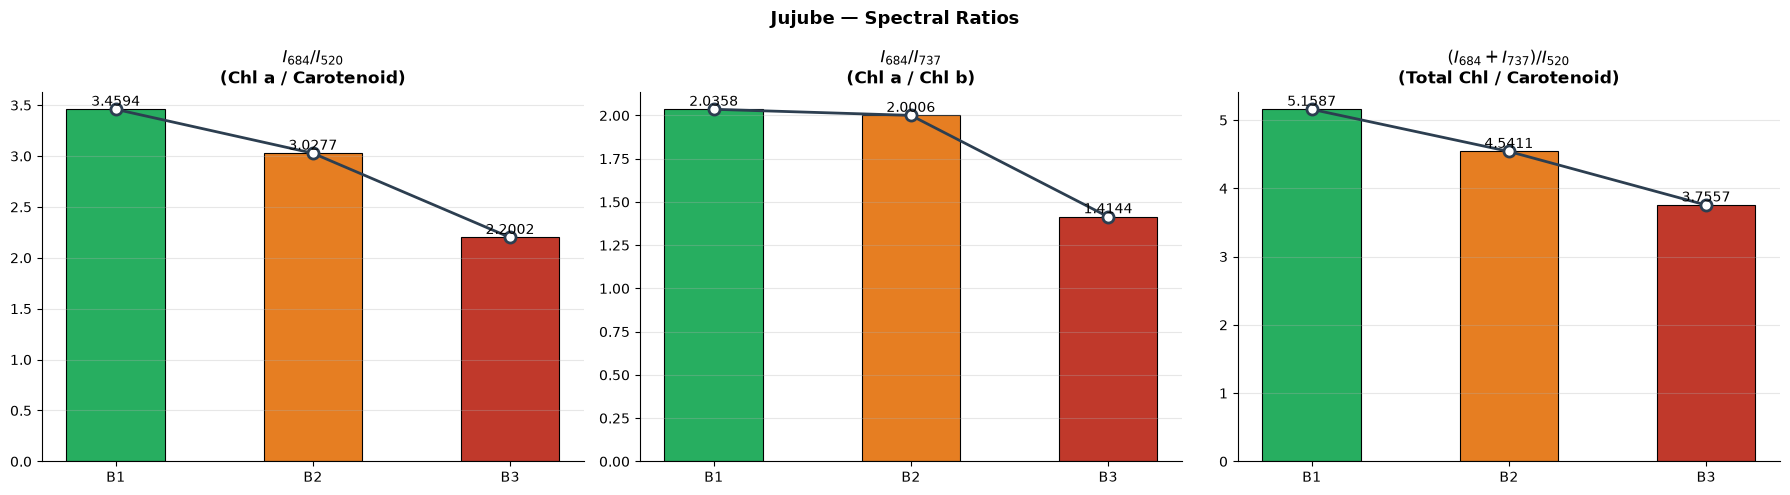

In [1]:
"""
=============================================================================
INDIAN Jujube SPECTRAL RATIO ANALYSIS
Ratios: I684/I520 | I684/I737 | (I684+I737)/I520
520nm = Carotenoid absorption band (primary pigment in jujube)
684nm = Chlorophyll a peak (dynamic detection)
737nm = Chlorophyll b peak (dynamic detection)
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# =============================================================================
# SECTION 1: FILE PATHS
# =============================================================================

B1_files = [
    r"Data\Jujube\SpectralData_Jujube\B1_S1.txt",
    r"Data\Jujube\SpectralData_Jujube\B1_S2.txt",
]

B2_files = [
    r"Data\Jujube\SpectralData_Jujube\B2_S1.txt",
    r"Data\Jujube\SpectralData_Jujube\B2_S2.txt",
]

B3_files = [
    r"Data\Jujube\SpectralData_Jujube\B3_S1.txt",
    r"Data\Jujube\SpectralData_Jujube\B3_S2.txt",
]

# =============================================================================
# SECTION 2: LOAD + AVERAGE
# =============================================================================

def load_and_average(file_list, wl_min=450, wl_max=900):
    datasets    = [np.loadtxt(f) for f in file_list]
    wavelength  = datasets[0][:, 0]
    intensities = np.array([d[:, 1] for d in datasets])

    mask        = (wavelength >= wl_min) & (wavelength <= wl_max)
    wavelength  = wavelength[mask]
    intensities = intensities[:, mask]
    I_avg       = np.mean(intensities, axis=0)

    return wavelength, intensities, I_avg

wavelength, B1_subs, I_avg_1 = load_and_average(B1_files)
_,          B2_subs, I_avg_2 = load_and_average(B2_files)
_,          B3_subs, I_avg_3 = load_and_average(B3_files)

# =============================================================================
# SECTION 3: NORMALIZATION ONLY (peak + area)
# =============================================================================

def normalize(I, wl):
    I_peak = I / np.max(I)
    return I_peak / trapezoid(I_peak, wl)

I_norm_1 = normalize(I_avg_1, wavelength)
I_norm_2 = normalize(I_avg_2, wavelength)
I_norm_3 = normalize(I_avg_3, wavelength)

# =============================================================================
# SECTION 4: PEAK DETECTION FUNCTIONS
# =============================================================================

def find_peak_near(spectrum, wl_array, target, search_window=20):
    """
    Find actual peak within ±search_window nm of target.
    Returns (peak_wavelength, peak_intensity).
    """
    mask     = (wl_array >= target - search_window) & \
               (wl_array <= target + search_window)
    local_wl = wl_array[mask]
    local_sp = spectrum[mask]
    peak_idx = np.argmax(local_sp)
    return local_wl[peak_idx], local_sp[peak_idx]

def get_I(spectrum, wl_array, target, window=5):
    """Mean intensity in ±window nm — used for broad/flat bands like carotenoid."""
    mask = (wl_array >= target - window) & (wl_array <= target + window)
    return np.mean(spectrum[mask])

# =============================================================================
# SECTION 5: RATIOS
# 520nm = carotenoid band (mean window — broad absorption)
# 684nm = Chl a peak      (dynamic peak detection)
# 737nm = Chl b peak      (dynamic peak detection)
# =============================================================================

def compute_ratios(spectrum, wl, search_window=20):
    I_car          = get_I(spectrum, wl, 520, window=5)   # carotenoid @ 520nm
    wl_520         = 520.0

    wl_684, I_chla = find_peak_near(spectrum, wl, 684, search_window)
    wl_737, I_chlb = find_peak_near(spectrum, wl, 737, search_window)

    r1 = I_chla / I_car                   # Chl a / Carotenoid
    r2 = I_chla / I_chlb                  # Chl a / Chl b
    r3 = (I_chla + I_chlb) / I_car        # Total Chl / Carotenoid

    return r1, r2, r3, I_car, I_chla, I_chlb, wl_520, wl_684, wl_737

R_B1 = compute_ratios(I_norm_1, wavelength)
R_B2 = compute_ratios(I_norm_2, wavelength)
R_B3 = compute_ratios(I_norm_3, wavelength)

# Detected peak wavelengths per sample
peak_wl_dict = {
    'B1': {'wl_520': R_B1[6], 'wl_684': R_B1[7], 'wl_737': R_B1[8]},
    'B2': {'wl_520': R_B2[6], 'wl_684': R_B2[7], 'wl_737': R_B2[8]},
    'B3': {'wl_520': R_B3[6], 'wl_684': R_B3[7], 'wl_737': R_B3[8]},
}

ratio_names = [
    r'$I_{684}/I_{520}$'           + '\n(Chl a / Carotenoid)',
    r'$I_{684}/I_{737}$'           + '\n(Chl a / Chl b)',
    r'$(I_{684}+I_{737})/I_{520}$' + '\n(Total Chl / Carotenoid)',
]

ratios = {
    'B1': R_B1[:3],
    'B2': R_B2[:3],
    'B3': R_B3[:3],
}

# =============================================================================
# SECTION 6: PRINT RESULTS
# =============================================================================

print("=" * 70)
print("Jujube — DETECTED PEAK WAVELENGTHS")
print("=" * 70)
print(f"{'Sample':<8} {'wl_520':>10} {'wl_684_actual':>15} {'wl_737_actual':>15}")
print("-" * 55)
for name, R in zip(['B1', 'B2', 'B3'], [R_B1, R_B2, R_B3]):
    print(f"{name:<8} {R[6]:>10.2f} {R[7]:>15.2f} {R[8]:>15.2f}")

print("\n" + "=" * 70)
print("Jujube — KEY WAVELENGTH INTENSITIES (normalized)")
print("=" * 70)
print(f"{'Sample':<8} {'I520(Car)':>12} {'I_pk684(Chla)':>15} {'I_pk737(Chlb)':>15}")
print("-" * 55)
for name, R in zip(['B1', 'B2', 'B3'], [R_B1, R_B2, R_B3]):
    print(f"{name:<8} {R[3]:>12.6f} {R[4]:>15.6f} {R[5]:>15.6f}")

print("\n" + "=" * 70)
print("Jujube — SPECTRAL RATIOS (dynamic peak detection)")
print("=" * 70)
print(f"{'Sample':<8} {'I684/I520':>15} {'I684/I737':>15} {'(I684+I737)/I520':>20}")
print("-" * 65)
for name, R in zip(['B1', 'B2', 'B3'], [R_B1, R_B2, R_B3]):
    print(f"{name:<8} {R[0]:>15.4f} {R[1]:>15.4f} {R[2]:>20.4f}")

# =============================================================================
# SECTION 7: RAW SPECTRA 
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle('Jujube — Raw Sub-samples + Average Spectrum',
             fontsize=13, fontweight='bold')

sub_colors = ['#aad4f5', '#74b9e8']

for ax, subs, I_avg, label in zip(
    axes,
    [B1_subs, B2_subs, B3_subs],
    [I_avg_1, I_avg_2, I_avg_3],
    ['B1', 'B2', 'B3']
):
    for i, sub in enumerate(subs):
        ax.plot(wavelength, sub, linestyle='--', color=sub_colors[i],
                linewidth=1, label=f'S{i+1}', alpha=0.7)

    ax.plot(wavelength, I_avg, 'k-', linewidth=2.5, label='Average')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Intensity (counts)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('RawSpectraJujube', dpi=600, bbox_inches='tight')
plt.show()

# =============================================================================
# SECTION 8: RAW + NORMALIZED 
# actual detected peaks marked per sample on normalized plot
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Jujube — Raw Average & Normalized Spectra',
             fontsize=13, fontweight='bold')

colors    = ['#27ae60', '#e67e22', '#c0392b']
names     = ['B1', 'B2', 'B3']
avg_list  = [I_avg_1, I_avg_2, I_avg_3]
norm_list = [I_norm_1, I_norm_2, I_norm_3]

# Nominal reference lines
ref_wls  = [520,           684,          737        ]
ref_lbls = ['520\nCar',    '684\nChl a', '737\nChl b']

for I, color, name in zip(avg_list, colors, names):
    ax1.plot(wavelength, I, color=color, linewidth=2, label=name)

for I, color, name in zip(norm_list, colors, names):
    ax2.plot(wavelength, I, color=color, linewidth=2, label=name)

# Gray dotted nominal lines on both axes
for ax in [ax1, ax2]:
    for wl_ref, lbl in zip(ref_wls, ref_lbls):
        ax.axvline(wl_ref, color='gray', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(wl_ref, ax.get_ylim()[1] * 0.92, lbl,
                ha='center', fontsize=8)
    ax.set_xlabel('Wavelength (nm)')
    ax.legend()
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Actual detected peaks marked on normalized plot only
for color, name in zip(colors, names):
    pk684 = peak_wl_dict[name]['wl_684']
    pk737 = peak_wl_dict[name]['wl_737']
    ax2.axvline(pk684, color=color, linestyle='--', linewidth=0.8, alpha=0.5)
    ax2.axvline(pk737, color=color, linestyle='--', linewidth=0.8, alpha=0.5)
    ax2.text(pk684, ax2.get_ylim()[0], f'{pk684:.0f}',
             ha='center', fontsize=7, color=color, va='bottom')
    ax2.text(pk737, ax2.get_ylim()[0], f'{pk737:.0f}',
             ha='center', fontsize=7, color=color, va='bottom')

ax1.set_title('Raw Average Spectra')
ax2.set_title('Normalized Spectra')

plt.tight_layout()
plt.savefig('Average_Normalized_Plot.png', dpi=600, bbox_inches='tight')
plt.show()

# =============================================================================
# SECTION 9: RATIO PLOTS
# =============================================================================

x      = np.array([1, 2, 3])
x_lbls = ['B1', 'B2', 'B3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Jujube — Spectral Ratios',
             fontsize=13, fontweight='bold')

bar_colors  = ['#27ae60', '#e67e22', '#c0392b']
trend_color = '#2c3e50'

for idx, (ax, rname) in enumerate(zip(axes, ratio_names)):
    vals = [ratios['B1'][idx], ratios['B2'][idx], ratios['B3'][idx]]

    bars = ax.bar(x, vals, color=bar_colors, width=0.5,
                  edgecolor='black', linewidth=0.8)

    ax.plot(x, vals, 'o-', color=trend_color,
            linewidth=2, markersize=8,
            markerfacecolor='white', markeredgewidth=2)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01 * max(vals),
                f'{val:.4f}', ha='center')

    ax.set_title(rname, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_lbls)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Jujube_ratio_plots.png', dpi=600, bbox_inches='tight')
plt.show()